# Allotax Test

Fitz Koch  
2026-04-22

# Setup

Navigate to root:

In [1]:
import sys, os
from pathlib import Path

_project_root = Path.cwd()
while not (_project_root / "src").exists():
    _project_root = _project_root.parent
os.chdir(_project_root)

# Imports

In [2]:
## std lib
from pathlib import Path
from itertools import product
import json
from ast import literal_eval
import pprint


## 3rd p lib
from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import seaborn as sns
from py_allotax.generate_svg import generate_svg

## project
from src.node import INTERNALS
from src.run import TERMINAL_DICT, BASE_TERMINALS, DEICTIC_TERMINALS, NAME_TERMINALS
from src.config_parser import Config, load_config



# constants
IMG_WIDTH = 12
IMG_HEIGHT = 6
plt.style.use(["ggplot"])

# Load Data

It’s big, so we’ll start with one line:

In [3]:
experiment = "Default"
result_path = Path("results")
path_end = "pride_history.jsonl"
terminal = "Base"
strategy = "Free"
file_path = result_path / experiment / terminal / strategy / path_end
config_path = Path("configs") / f"{experiment}.toml"
config = load_config(config_path)
line = ""
with open(file_path) as f:
    for gen, line in enumerate(f):
        print(gen)
        print(line[:50])
        line = line

0
[[{"op": "*2", "children": [{"op": "if>=", "childr
1
[[{"op": "+", "children": [{"op": "*2", "children"
2
[[{"op": "rand", "children": [{"op": "rand", "chil
3
[[{"op": "->90", "children": [{"op": "ifdot", "chi
4
[[{"op": "+", "children": [{"op": "*2", "children"
5
[[{"op": "ifdot", "children": [{"op": "inv", "chil
6
[[{"op": "+", "children": [{"op": "*2", "children"
7
[[{"op": "ifdot", "children": [{"op": "inv", "chil
8
[[{"op": "->90", "children": [{"op": "->90", "chil
9
[[{"op": "ifdot", "children": [{"op": "inv", "chil
10
[[{"op": "ifdot", "children": [{"op": "inv", "chil
11
[[{"op": "ifdot", "children": [{"op": "inv", "chil
12
[[{"op": "ifdot", "children": [{"op": "inv", "chil
13
[[{"op": "ifdot", "children": [{"op": "inv", "chil
14
[[{"op": "ifdot", "children": [{"op": "inv", "chil
15
[[{"op": "ifdot", "children": [{"op": "inv", "chil
16
[[{"op": "ifdot", "children": [{"op": "inv", "chil
17
[[{"op": "ifdot", "children": [{"op": "inv", "chil
18
[[{"op": "ifdot", "children": [{"op

In [4]:
terminals_used = TERMINAL_DICT[terminal]
print(terminals_used)

['last', 'rand-dir', 'gazelle']

# Building Count Operations

In [5]:
prides = literal_eval(line)

In [6]:
print(prides[0][0])

{'op': 'ifdot', 'children': [{'op': 'inv', 'children': [{'op': 'last', 'children': []}]}, {'op': 'last', 'children': []}, {'op': 'gazelle', 'children': []}, {'op': '->90', 'children': [{'op': 'rand', 'children': [{'op': 'if>=', 'children': [{'op': 'rand-dir', 'children': []}, {'op': 'rand-dir', 'children': []}, {'op': 'ifdot', 'children': [{'op': 'last', 'children': []}, {'op': 'rand-dir', 'children': []}, {'op': '-', 'children': [{'op': 'rand-dir', 'children': []}]}, {'op': '*2', 'children': [{'op': 'inv', 'children': [{'op': 'gazelle', 'children': []}]}]}]}, {'op': 'ifdot', 'children': [{'op': 'inv', 'children': [{'op': 'rand', 'children': [{'op': 'gazelle', 'children': []}]}]}, {'op': 'rand-dir', 'children': []}, {'op': 'inv', 'children': [{'op': 'inv', 'children': [{'op': '+', 'children': [{'op': '/2', 'children': [{'op': '->90', 'children': [{'op': '/2', 'children': [{'op': 'gazelle', 'children': []}]}]}]}, {'op': '->90', 'children': [{'op': '->90', 'children': [{'op': 'gazelle', 

In [7]:
def build_counts():
  counts = {
    operator : [0 for _ in range(config.max_depth+1)] #  TODO: Change once rerun with max_depth bug fixed
    for operator in terminals_used+INTERNALS
  }
  return counts

Look at a single lion:

In [8]:
def count_operations(node, level=0, counts=None):
  if counts is None:
    counts = build_counts()
  op = node['op']
  counts[op][level] += 1
  for child in node["children"]: 
    count_operations(child, level+1, counts)
  return counts

counts = count_operations(prides[0][0])
pprint.pprint(counts)

{'*2': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 '+': [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 '-': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 '->90': [0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0],
 '/2': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'gazelle': [0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
 'if>=': [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'ifdot': [1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'inv': [0, 1, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'last': [0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'rand': [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'rand-dir': [0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

Look at a pride:

In [9]:
counts = build_counts()
for lion in prides[0]:
  counts = count_operations(lion, level=0, counts=counts)
pprint.pprint(counts)

{'*2': [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 6, 2, 0],
 '+': [1, 2, 2, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 1, 4, 2, 1, 0],
 '-': [0, 0, 0, 1, 1, 1, 0, 1, 2, 0, 1, 2, 0, 3, 4, 3, 3, 0],
 '->90': [0, 2, 0, 1, 0, 0, 1, 1, 1, 2, 1, 2, 2, 0, 0, 2, 1, 0],
 '/2': [0, 0, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 0, 4, 3, 2, 2, 0],
 'gazelle': [0, 4, 8, 3, 1, 1, 4, 2, 1, 1, 2, 1, 1, 1, 3, 3, 3, 15],
 'if>=': [1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 3, 1, 1, 4, 0],
 'ifdot': [2, 2, 2, 1, 3, 1, 0, 0, 0, 0, 0, 0, 3, 1, 3, 2, 1, 0],
 'inv': [0, 1, 3, 4, 0, 6, 4, 0, 0, 0, 1, 0, 2, 2, 3, 4, 9, 0],
 'last': [0, 2, 1, 5, 4, 4, 1, 0, 1, 1, 0, 2, 1, 1, 2, 3, 3, 11],
 'rand': [0, 0, 1, 0, 3, 1, 1, 1, 1, 3, 1, 0, 1, 0, 1, 2, 2, 0],
 'rand-dir': [0, 0, 0, 0, 2, 3, 1, 0, 1, 0, 0, 0, 1, 1, 2, 6, 4, 15]}

Look at a generation:

In [10]:
counts = build_counts()
for pride in prides:
  for lion in pride:
    counts = count_operations(lion, level=0, counts=counts)
pprint.pprint(counts)

{'*2': [15,
        32,
        110,
        49,
        39,
        127,
        111,
        400,
        105,
        10,
        187,
        192,
        72,
        3,
        256,
        823,
        290,
        0],
 '+': [483,
       1046,
       543,
       356,
       120,
       67,
       175,
       135,
       50,
       351,
       30,
       276,
       9,
       257,
       696,
       274,
       137,
       0],
 '-': [0,
       20,
       68,
       274,
       366,
       99,
       122,
       334,
       602,
       11,
       224,
       299,
       45,
       473,
       548,
       531,
       528,
       0],
 '->90': [5,
          191,
          205,
          438,
          402,
          330,
          455,
          417,
          44,
          37,
          357,
          487,
          295,
          86,
          37,
          418,
          138,
          0],
 '/2': [38,
        23,
        326,
        700,
        511,
        372,
        586,
    

Cool, that seems to be working. But probably it makes the most sense to have these in a dataframe.

In [11]:
df = pd.DataFrame.from_dict(counts, orient="index")
df.head()

Great, this looks good. The column index are what ‘hierarchy’ the operation is in, with $0$ being the top of the chain and $17$ the lowest (there’s a slight bug with `max_depth` where I did $\ge$ as the redo condition for initial construction and $>$ for crossover, which will require a redo for proper results, but is okay).

# Getting Results

Quick inspection of the first line…

In [12]:
print(file_path)
with open(file_path) as f:
    line = f.readline()
line = line
prides = literal_eval(line)
print(prides[0][0])

results/Default/Base/Free/pride_history.jsonl
{'op': '*2', 'children': [{'op': 'if>=', 'children': [{'op': '+', 'children': [{'op': 'rand-dir', 'children': []}, {'op': 'last', 'children': []}]}, {'op': '+', 'children': [{'op': 'gazelle', 'children': []}, {'op': '/2', 'children': [{'op': 'rand', 'children': [{'op': '/2', 'children': [{'op': '->90', 'children': [{'op': '*2', 'children': [{'op': '->90', 'children': [{'op': '+', 'children': [{'op': '/2', 'children': [{'op': 'gazelle', 'children': []}]}, {'op': 'rand', 'children': [{'op': '+', 'children': [{'op': '/2', 'children': [{'op': 'inv', 'children': [{'op': '*2', 'children': [{'op': 'rand-dir', 'children': []}]}]}]}, {'op': '->90', 'children': [{'op': 'last', 'children': []}]}]}]}]}]}]}]}]}]}]}]}, {'op': 'inv', 'children': [{'op': 'ifdot', 'children': [{'op': 'last', 'children': []}, {'op': '+', 'children': [{'op': '*2', 'children': [{'op': '*2', 'children': [{'op': 'ifdot', 'children': [{'op': 'inv', 'children': [{'op': 'inv', 'chi

Looks good.

In [13]:
def get_gen_op_counts(file_path, gen_idx):
    with open(file_path) as f:
        for i, line in enumerate(f):
            if i == gen_idx:
                population = json.loads(line)
                break
    
    counts = build_counts()
    for pride in population:
        for lion in pride:
            count_operations(lion, 0, counts)
    df = pd.DataFrame.from_dict(counts, orient="index")
    return df

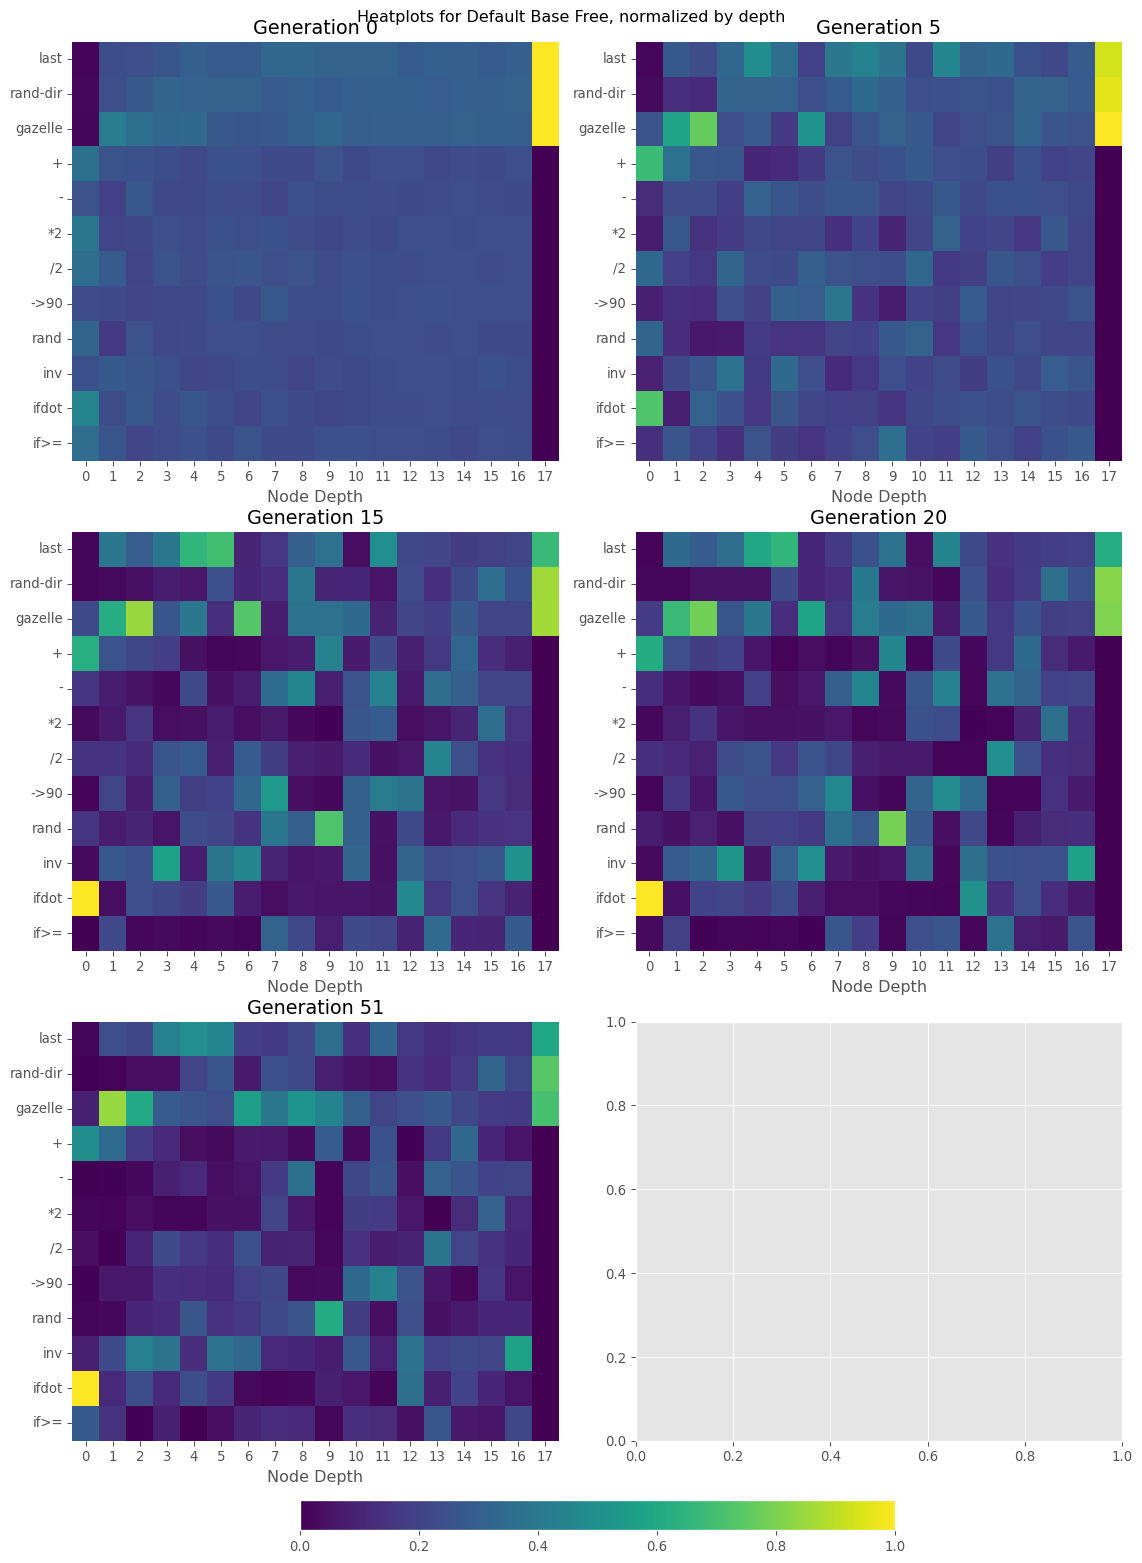

In [14]:
generations_of_interest = [0, 5, 15, 20,  51]
dfs = [get_gen_op_counts(file_path, gen) for gen in generations_of_interest]
n_gen = len(generations_of_interest)
n_rows = (n_gen + 1) // 2

fig, axes = plt.subplots(n_rows,  2, figsize=(IMG_WIDTH, IMG_HEIGHT*n_rows))
axes = axes.flatten()

for i, (ax, df, title) in enumerate(zip(axes, dfs, [f"Generation {gen}" for gen in generations_of_interest])):
    df = df.div(df.sum()) ## normalize by column (depth)
    sns.heatmap(df, ax=ax, cmap="viridis", annot=False, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("Node Depth")
plt.suptitle(f"Heatplots for {experiment} {terminal} {strategy}, normalized by depth")
plt.tight_layout()
fig.subplots_adjust(bottom=0.1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", 
                    fraction=0.02, pad=0.04, location="bottom")
plt.show()

Text(0.5, 1.0, 'Depth profile across generations — Default Base Free')

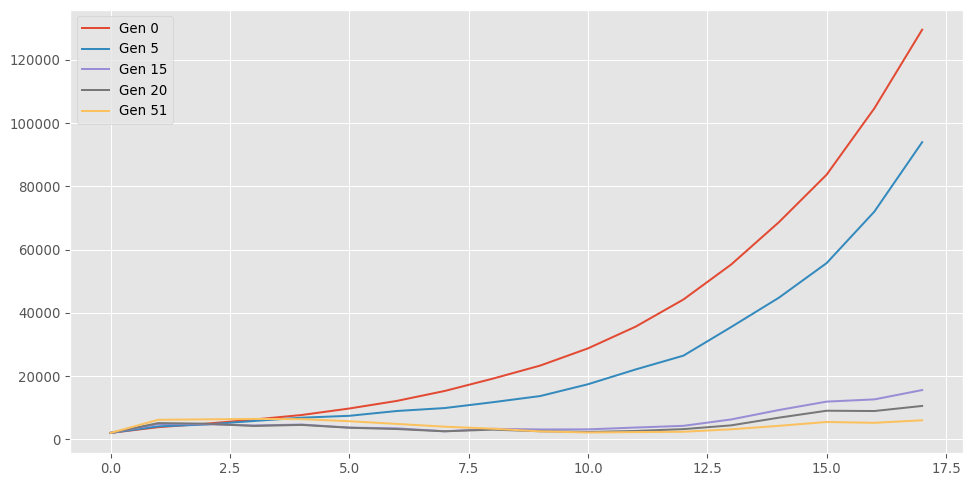

In [15]:
def get_depth_profile(df):
    return df.sum(axis=0)  # sum all ops at each depth level

depth_profiles = pd.DataFrame(
    {f"Gen {gen}": get_depth_profile(df) for gen, df in zip(generations_of_interest, dfs)}
)

depth_profiles.plot(figsize=(IMG_WIDTH, IMG_HEIGHT))
ax.set_xlabel("Depth")
ax.set_ylabel("Node count")
ax.set_title(f"Depth profile across generations — {experiment} {terminal} {strategy}")

Great, looks good, now we’ll turn this into functions in `src` and run them on all our experiments that way, too.

To check:

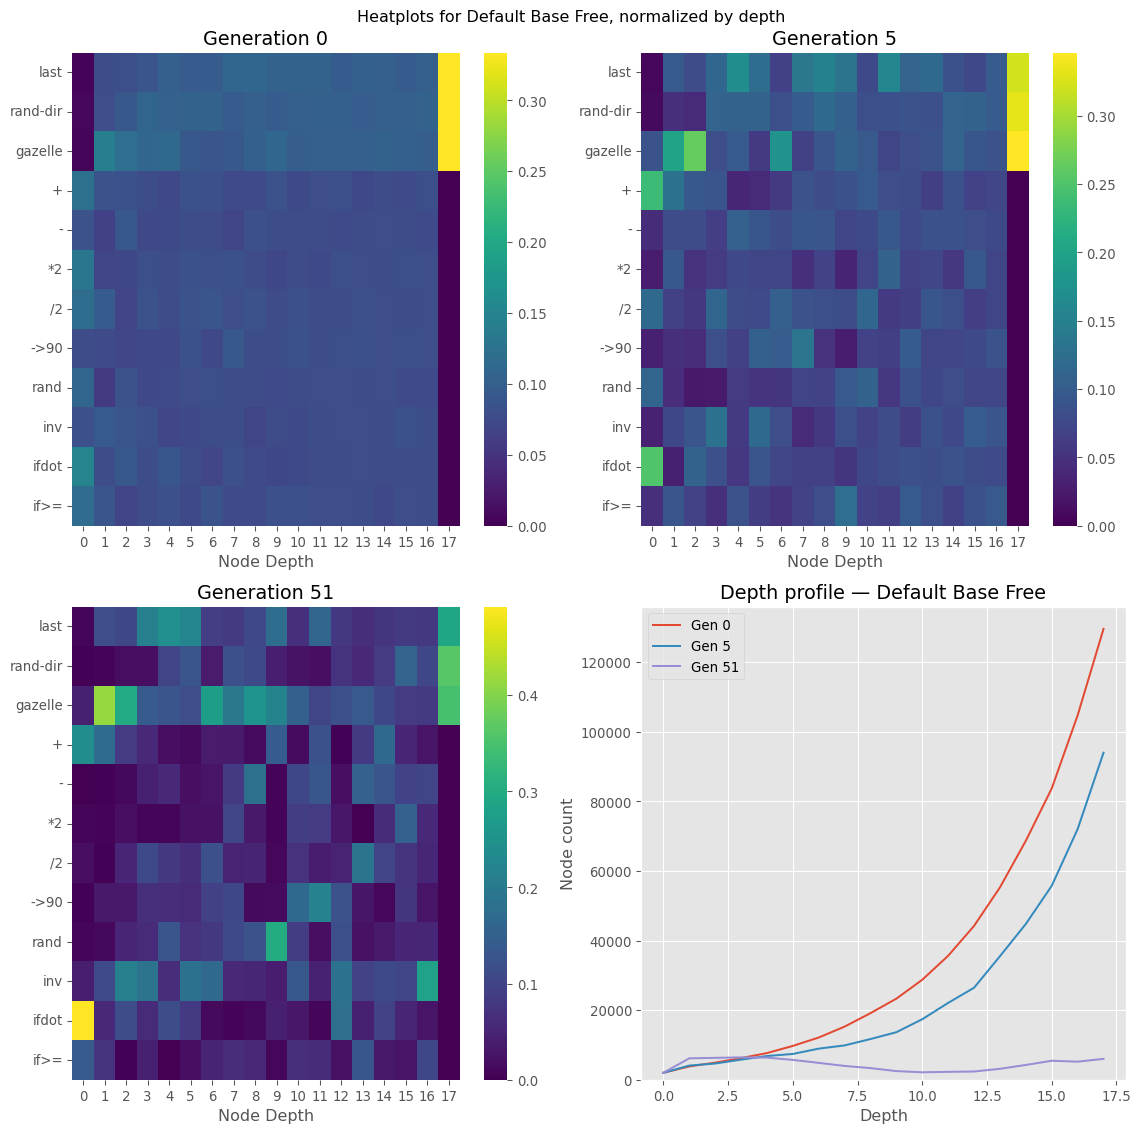

In [16]:
def plot_depths(gens, dfs, ax, title_specs):
    depth_profiles = pd.DataFrame(
        {f"Gen {gen}": df.sum(axis=0) for gen, df in zip(gens, dfs)}
    )
    depth_profiles.plot(ax=ax)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Node count")
    ax.set_ylim(bottom=0)
    ax.set_title(f"Depth profile — {title_specs}")


def plot_heatmaps(file_path, gens, title_spec):
    dfs = [get_gen_op_counts(file_path, gen) for gen in gens]
    n_axes = len(gens) + 1
    n_rows = (n_axes + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(IMG_WIDTH, IMG_HEIGHT * n_rows))
    axes = axes.flatten()

    for i, (ax, df, title) in enumerate(
        zip(axes, dfs, [f"Generation {gen}" for gen in gens])
    ):
        df = df.div(df.sum())  ## normalize by column (depth)
        sns.heatmap(df, ax=ax, cmap="viridis", annot=False, cbar=True)
        ax.set_title(title)
        ax.set_xlabel("Node Depth")

    plot_depths(gens, dfs, axes[len(gens)], title_spec)
    plt.suptitle(f"Heatplots for {title_spec}, normalized by depth")
    plt.tight_layout()
    plt.show()

plot_heatmaps(file_path=file_path, gens=[0, 5, 51], title_spec=f"{experiment} {terminal} {strategy}" )